<a href="https://colab.research.google.com/github/suyashjaiswal235-jpg/iMAPP-Advanced-DL/blob/main/icecube_transformer_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IceCube 2D Transformer Encoder

This Colab notebook trains a PyTorch `TransformerEncoder` to reconstruct the 2D neutrino interaction position `(xpos, ypos)` from variable-length photon hit lists. Each photon/hit is represented by `(time, detector_x, detector_y)`.

Run the cells from top to bottom. When prompted, upload `IceCube 2D Dataset (1).zip`.

In [1]:
# Colab setup. Colab usually already has torch installed.
!pip -q install pyarrow scikit-learn tqdm reportlab pypdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 32.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.5/349.5 kB 13.0 MB/s eta 0:00:00


In [10]:
from pathlib import Path
import zipfile

DATA_ROOT = Path('/content')
DATA_DIR = DATA_ROOT / 'IceCube 2D Dataset'

if not DATA_DIR.exists():
    try:
        from google.colab import files
        print('Upload IceCube 2D Dataset (1).zip')
        uploaded = files.upload()
        zip_candidates = [name for name in uploaded if name.lower().endswith('.zip')]
        if not zip_candidates:
            raise FileNotFoundError('No .zip file was uploaded.')
        zip_path = Path(zip_candidates[0])
    except ModuleNotFoundError:
        zip_path = Path('IceCube 2D Dataset (1).zip')
        if not zip_path.exists():
            raise FileNotFoundError('Place IceCube 2D Dataset (1).zip next to this notebook, or run in Colab and upload it.')

    with zipfile.ZipFile(zip_path) as zf:
        zf.extractall(DATA_ROOT)

print('Dataset directory:', DATA_DIR)
print('Files:', sorted(path.name for path in DATA_DIR.glob('*.pq')))

Upload IceCube 2D Dataset (1).zip


Saving IceCube 2D Dataset (1).zip to IceCube 2D Dataset (1).zip
Dataset directory: /content/IceCube 2D Dataset
Files: ['test.pq', 'train.pq', 'val.pq']


In [3]:
import json
import math
import random
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from matplotlib.backends.backend_pdf import PdfPages
from reportlab.lib.pagesizes import A4
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.platypus import Paragraph, SimpleDocTemplate, Spacer
from sklearn.metrics import r2_score
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader, Dataset, Subset
from tqdm.auto import tqdm

# Hyperparameters. For a quick test, set MAX_TRAIN/MAX_VAL/MAX_TEST to smaller numbers.
EPOCHS = 30
BATCH_SIZE = 256
LR = 2e-3
WEIGHT_DECAY = 1e-4
D_MODEL = 64
N_HEADS = 4
NUM_LAYERS = 2
DIM_FEEDFORWARD = 128
DROPOUT = 0.05
PATIENCE = 8
SEED = 123

MAX_TRAIN = None
MAX_VAL = None
MAX_TEST = None

OUTPUT_DIR = Path('/content/icecube_transformer_outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


In [4]:
@dataclass
class Normalizer:
    mean: np.ndarray
    std: np.ndarray

    @classmethod
    def from_array(cls, values):
        mean = values.mean(axis=0).astype(np.float32)
        std = values.std(axis=0).astype(np.float32)
        std = np.where(std < 1e-6, 1.0, std).astype(np.float32)
        return cls(mean=mean, std=std)

    def transform(self, values):
        return (values - self.mean) / self.std

    def inverse(self, values):
        return values * self.std + self.mean

    def to_dict(self):
        return {'mean': self.mean.tolist(), 'std': self.std.tolist()}


class IceCube2DDataset(Dataset):
    def __init__(self, path, feature_norm=None, label_norm=None):
        self.path = Path(path)
        self.frame = pd.read_parquet(self.path).reset_index(drop=True)
        self.feature_norm = feature_norm
        self.label_norm = label_norm

    def __len__(self):
        return len(self.frame)

    @staticmethod
    def event_to_features(raw_event):
        # raw_event is [time_array, detector_x_array, detector_y_array]
        channels = [np.asarray(channel, dtype=np.float32) for channel in raw_event]
        return np.stack(channels, axis=1)  # shape: (n_hits, 3)

    def raw_features(self, index):
        return self.event_to_features(self.frame.iloc[index]['data'])

    def raw_label(self, index):
        row = self.frame.iloc[index]
        return np.asarray([row['xpos'], row['ypos']], dtype=np.float32)

    def __getitem__(self, index):
        features = self.raw_features(index)
        labels = self.raw_label(index)
        hit_count = float(features.shape[0])

        if self.feature_norm is not None:
            features = self.feature_norm.transform(features).astype(np.float32)
        if self.label_norm is not None:
            labels = self.label_norm.transform(labels).astype(np.float32)

        return {'data': features, 'labels': labels, 'hit_count': hit_count}


def estimate_normalizers(dataset):
    feature_blocks = [dataset.raw_features(i) for i in range(len(dataset))]
    all_features = np.concatenate(feature_blocks, axis=0)
    all_labels = np.stack([dataset.raw_label(i) for i in range(len(dataset))], axis=0)
    return Normalizer.from_array(all_features), Normalizer.from_array(all_labels)


def collate_fn_transformer(batch):
    data_list = []
    labels = []
    lengths = []

    for event in batch:
        tensor_data = torch.as_tensor(event['data'], dtype=torch.float32)
        data_list.append(tensor_data)
        lengths.append(tensor_data.shape[0])
        labels.append(torch.as_tensor(event['labels'], dtype=torch.float32).unsqueeze(0))

    # Keep hits compact here; padding happens inside the model.
    return [torch.cat(data_list, dim=0), lengths], torch.cat(labels, dim=0)


def subset_if_requested(dataset, max_events, seed):
    if max_events is None or max_events >= len(dataset):
        return dataset
    generator = np.random.default_rng(seed)
    indices = generator.choice(len(dataset), size=max_events, replace=False)
    return Subset(dataset, indices.tolist())

In [5]:
class TransformerEncoderRegressor(nn.Module):
    def __init__(
        self,
        input_dim=3,
        output_dim=2,
        d_model=64,
        n_heads=4,
        num_layers=2,
        dim_feedforward=128,
        dropout=0.05,
    ):
        super().__init__()
        self.input_embedding = nn.Sequential(
            nn.Linear(input_dim, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
        )
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=dim_feedforward,
            activation='gelu',
            batch_first=True,
            norm_first=True,
            dropout=dropout,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.output_projection = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, output_dim),
        )

    def forward(self, data):
        src, lengths = data

        # 1) Embed each photon from 3 input features to d_model.
        src = self.input_embedding(src)

        # 2) Split concatenated hits back into one tensor per event.
        parts = src.split(lengths, dim=0)

        # 3) Pad events to the longest sequence in the batch.
        padded = pad_sequence(parts, batch_first=True)
        batch_size, max_len, _ = padded.shape

        # 4) Build a padding mask where True means padding.
        mask = torch.zeros(batch_size, max_len, dtype=torch.bool, device=padded.device)
        for i, length in enumerate(lengths):
            mask[i, length:] = True

        # 5) Transformer encoder ignores padded tokens through the mask.
        enc_out = self.encoder(padded, src_key_padding_mask=mask)

        # 6) Masked mean pooling over real photon hits.
        valid_mask = ~mask
        summed = (enc_out * valid_mask.unsqueeze(-1)).sum(dim=1)
        denominator = torch.as_tensor(lengths, dtype=enc_out.dtype, device=enc_out.device).unsqueeze(1)
        pooled = summed / denominator.clamp_min(1.0)

        # 7) Regression head predicts x/y position.
        return self.output_projection(pooled)

In [6]:
def move_batch_to_device(batch, device):
    data, labels = batch
    return [data[0].to(device), data[1]], labels.to(device)


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_examples = 0

    for batch in tqdm(loader, desc='train', leave=False):
        data, labels = move_batch_to_device(batch, device)
        optimizer.zero_grad(set_to_none=True)
        predictions = model(data)
        loss = criterion(predictions, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        batch_size = labels.shape[0]
        total_loss += loss.item() * batch_size
        total_examples += batch_size

    return total_loss / max(1, total_examples)


@torch.no_grad()
def evaluate_loss(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_examples = 0

    for batch in tqdm(loader, desc='validate', leave=False):
        data, labels = move_batch_to_device(batch, device)
        predictions = model(data)
        loss = criterion(predictions, labels)

        batch_size = labels.shape[0]
        total_loss += loss.item() * batch_size
        total_examples += batch_size

    return total_loss / max(1, total_examples)


@torch.no_grad()
def predict(model, loader, label_norm, device):
    model.eval()
    predictions = []
    targets = []
    hit_counts = []

    for batch in tqdm(loader, desc='predict', leave=False):
        data, labels = move_batch_to_device(batch, device)
        pred_norm = model(data).detach().cpu().numpy()
        target_norm = labels.detach().cpu().numpy()

        predictions.append(label_norm.inverse(pred_norm))
        targets.append(label_norm.inverse(target_norm))
        hit_counts.append(np.asarray(data[1], dtype=np.float32))

    return np.concatenate(predictions), np.concatenate(targets), np.concatenate(hit_counts)


def regression_metrics(predictions, targets):
    residuals = predictions - targets
    distance = np.linalg.norm(residuals, axis=1)
    mse_axis = np.mean(residuals**2, axis=0)
    mae_axis = np.mean(np.abs(residuals), axis=0)
    return {
        'mae_x_m': float(mae_axis[0]),
        'mae_y_m': float(mae_axis[1]),
        'rmse_x_m': float(math.sqrt(mse_axis[0])),
        'rmse_y_m': float(math.sqrt(mse_axis[1])),
        'mean_distance_error_m': float(distance.mean()),
        'median_distance_error_m': float(np.median(distance)),
        'p90_distance_error_m': float(np.percentile(distance, 90)),
        'r2_x': float(r2_score(targets[:, 0], predictions[:, 0])),
        'r2_y': float(r2_score(targets[:, 1], predictions[:, 1])),
    }

In [11]:
raw_train = IceCube2DDataset(DATA_DIR / 'train.pq')
feature_norm, label_norm = estimate_normalizers(raw_train)

train_dataset = IceCube2DDataset(DATA_DIR / 'train.pq', feature_norm, label_norm)
val_dataset = IceCube2DDataset(DATA_DIR / 'val.pq', feature_norm, label_norm)
test_dataset = IceCube2DDataset(DATA_DIR / 'test.pq', feature_norm, label_norm)

train_dataset = subset_if_requested(train_dataset, MAX_TRAIN, SEED)
val_dataset = subset_if_requested(val_dataset, MAX_VAL, SEED + 1)
test_dataset = subset_if_requested(test_dataset, MAX_TEST, SEED + 2)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn_transformer, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn_transformer, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn_transformer, num_workers=0)

print('Events:', len(train_dataset), 'train,', len(val_dataset), 'val,', len(test_dataset), 'test')
print('Feature mean:', feature_norm.mean)
print('Feature std:', feature_norm.std)
print('Label mean:', label_norm.mean)
print('Label std:', label_norm.std)

Events: 10001 train, 10001 val, 10001 test
Feature mean: [1.2492168e+01 1.0375453e-01 2.7357473e-03]
Feature std: [5.789235  1.8473122 1.8515621]
Label mean: [-0.03322223  0.00482481]
Label std: [5.0140038 4.956108 ]


In [12]:
model = TransformerEncoderRegressor(
    d_model=D_MODEL,
    n_heads=N_HEADS,
    num_layers=NUM_LAYERS,
    dim_feedforward=DIM_FEEDFORWARD,
    dropout=DROPOUT,
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
criterion = nn.MSELoss()

history = []
best_val = float('inf')
best_state = None
stale_epochs = 0

for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss = evaluate_loss(model, val_loader, criterion, device)
    scheduler.step(val_loss)

    history.append({'epoch': epoch, 'train_loss': train_loss, 'val_loss': val_loss})
    print(f'epoch {epoch:03d}: train_loss={train_loss:.5f} val_loss={val_loss:.5f}')

    if val_loss < best_val:
        best_val = val_loss
        best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
        stale_epochs = 0
    else:
        stale_epochs += 1
        if stale_epochs >= PATIENCE:
            print(f'early stopping after {epoch} epochs')
            break

if best_state is not None:
    model.load_state_dict(best_state)

/tmp/ipykernel_1026/4245179055.py:27: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


train:   0%|          | 0/40 [00:00<?, ?it/s]

validate:   0%|          | 0/40 [00:00<?, ?it/s]

epoch 001: train_loss=0.30359 val_loss=0.13405


train:   0%|          | 0/40 [00:00<?, ?it/s]

...

validate:   0%|          | 0/40 [00:00<?, ?it/s]

epoch 029: train_loss=0.05658 val_loss=0.07811


train:   0%|          | 0/40 [00:00<?, ?it/s]

validate:   0%|          | 0/40 [00:00<?, ?it/s]

epoch 030: train_loss=0.05540 val_loss=0.07814


In [13]:
predictions, targets, hit_counts = predict(model, test_loader, label_norm, device)
metrics = regression_metrics(predictions, targets)

pd.DataFrame([metrics]).T.rename(columns={0: 'value'})

predict:   0%|          | 0/40 [00:00<?, ?it/s]

,value
mae_x_m,0.762933
mae_y_m,0.874494
rmse_x_m,1.194180
rmse_y_m,1.522275
mean_distance_error_m,1.292385
median_distance_error_m,0.800914
p90_distance_error_m,2.919857
r2_x,0.943081
r2_y,0.906295


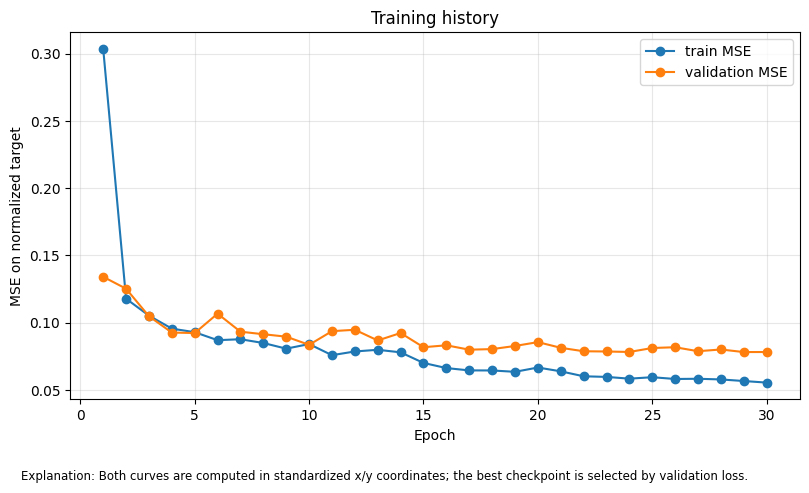

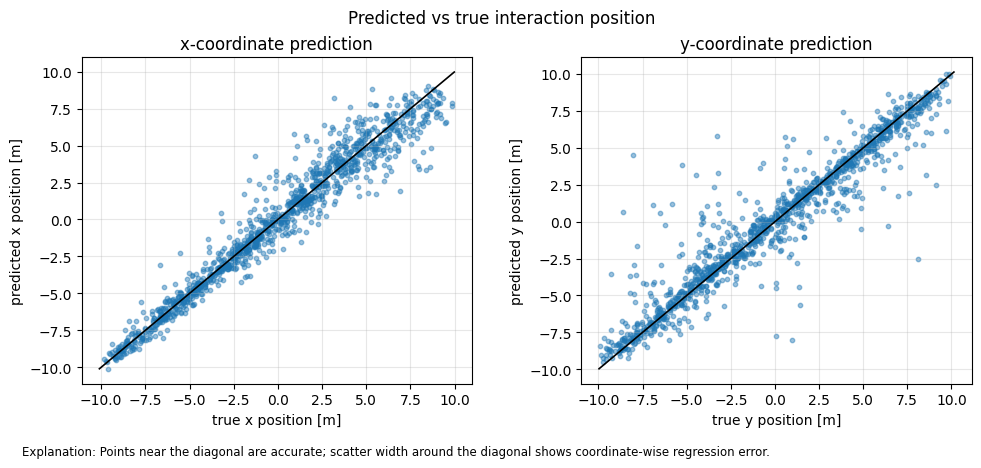

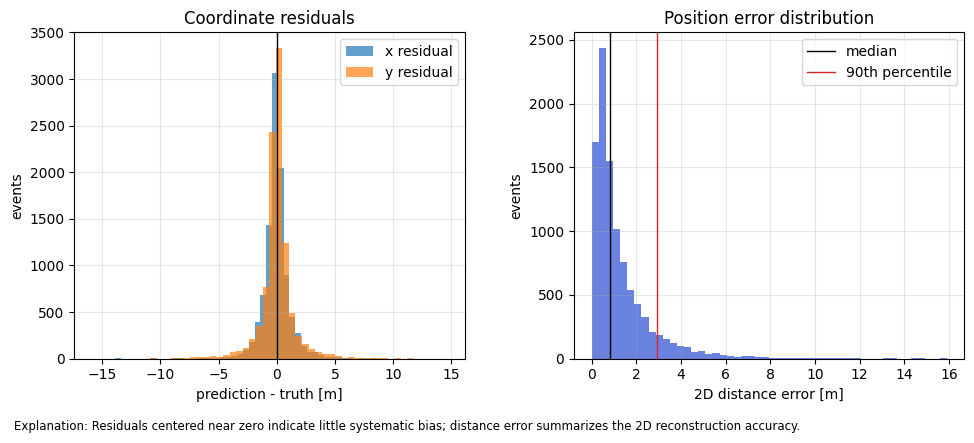

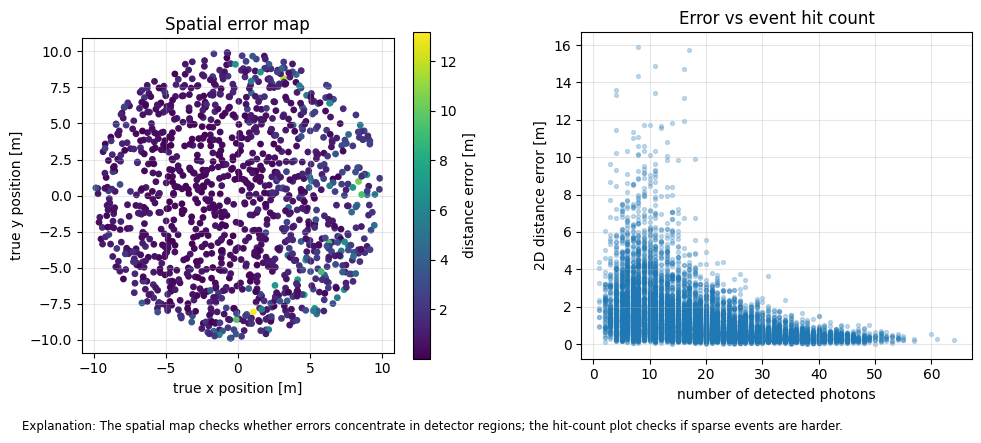

Saved plots to /content/icecube_transformer_outputs/result_plots.pdf


In [14]:
def save_plots(output_pdf, history, predictions, targets, hit_counts, metrics, show=True):
    residuals = predictions - targets
    distance = np.linalg.norm(residuals, axis=1)
    sample_size = min(1200, len(targets))
    rng = np.random.default_rng(7)
    sample = rng.choice(len(targets), size=sample_size, replace=False)
    figs = []

    fig, ax = plt.subplots(figsize=(8.2, 5.4))
    epochs = [item['epoch'] for item in history]
    ax.plot(epochs, [item['train_loss'] for item in history], marker='o', label='train MSE')
    ax.plot(epochs, [item['val_loss'] for item in history], marker='o', label='validation MSE')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE on normalized target')
    ax.set_title('Training history')
    ax.grid(True, alpha=0.3)
    ax.legend()
    figs.append(fig)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4.8))
    for dim, label, axis in [(0, 'x', axes[0]), (1, 'y', axes[1])]:
        axis.scatter(targets[sample, dim], predictions[sample, dim], s=10, alpha=0.45)
        lower = min(targets[:, dim].min(), predictions[:, dim].min())
        upper = max(targets[:, dim].max(), predictions[:, dim].max())
        axis.plot([lower, upper], [lower, upper], color='black', lw=1.2)
        axis.set_xlabel(f'true {label} position [m]')
        axis.set_ylabel(f'predicted {label} position [m]')
        axis.set_title(f'{label}-coordinate prediction')
        axis.grid(True, alpha=0.3)
    fig.suptitle('Predicted vs true interaction position')
    fig.tight_layout()
    figs.append(fig)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4.8))
    axes[0].hist(residuals[:, 0], bins=50, alpha=0.7, label='x residual')
    axes[0].hist(residuals[:, 1], bins=50, alpha=0.7, label='y residual')
    axes[0].axvline(0, color='black', lw=1)
    axes[0].set_xlabel('prediction - truth [m]')
    axes[0].set_ylabel('events')
    axes[0].set_title('Coordinate residuals')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].hist(distance, bins=50, color='#4363d8', alpha=0.8)
    axes[1].axvline(metrics['median_distance_error_m'], color='black', lw=1, label='median')
    axes[1].axvline(metrics['p90_distance_error_m'], color='tab:red', lw=1, label='90th percentile')
    axes[1].set_xlabel('2D distance error [m]')
    axes[1].set_ylabel('events')
    axes[1].set_title('Position error distribution')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    fig.tight_layout()
    figs.append(fig)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4.8))
    scatter = axes[0].scatter(targets[sample, 0], targets[sample, 1], c=distance[sample], s=15, cmap='viridis')
    axes[0].set_xlabel('true x position [m]')
    axes[0].set_ylabel('true y position [m]')
    axes[0].set_title('Spatial error map')
    axes[0].set_aspect('equal', adjustable='box')
    axes[0].grid(True, alpha=0.3)
    fig.colorbar(scatter, ax=axes[0], label='distance error [m]')

    axes[1].scatter(hit_counts, distance, s=8, alpha=0.25)
    axes[1].set_xlabel('number of detected photons')
    axes[1].set_ylabel('2D distance error [m]')
    axes[1].set_title('Error vs event hit count')
    axes[1].grid(True, alpha=0.3)
    fig.tight_layout()
    figs.append(fig)

    explanations = [
        'Both curves are computed in standardized x/y coordinates; the best checkpoint is selected by validation loss.',
        'Points near the diagonal are accurate; scatter width around the diagonal shows coordinate-wise regression error.',
        'Residuals centered near zero indicate little systematic bias; distance error summarizes the 2D reconstruction accuracy.',
        'The spatial map checks whether errors concentrate in detector regions; the hit-count plot checks if sparse events are harder.',
    ]

    with PdfPages(output_pdf) as pdf:
        for fig, explanation in zip(figs, explanations):
            fig.subplots_adjust(left=0.08, right=0.97, top=0.88, bottom=0.20, wspace=0.28)
            fig.text(0.02, 0.045, 'Explanation: ' + explanation, fontsize=8.5, ha='left', va='bottom', wrap=True)
            pdf.savefig(fig)
            if show:
                display(fig)
            plt.close(fig)


plots_path = OUTPUT_DIR / 'result_plots.pdf'
save_plots(plots_path, history, predictions, targets, hit_counts, metrics)
print('Saved plots to', plots_path)

In [15]:
summary = f"""# Transformer Encoder Summary

I implemented a PyTorch Transformer encoder to reconstruct the 2D neutrino interaction position from the variable-length list of detected photons. Each photon was represented by its detection time and the x/y detector coordinates, then standardized using statistics from the training set. Events were batched by concatenating their hits, storing the original lengths, padding inside the model, and passing a padding mask to a TransformerEncoder with {NUM_LAYERS} layers and {N_HEADS} attention heads. The encoded photons were mean-pooled over valid (non-padding) hits and passed through a small regression head to predict xpos and ypos.

The model was trained with AdamW and MSE loss on standardized target coordinates. I used {len(train_dataset)} training events, {len(val_dataset)} validation events, and {len(test_dataset)} test events. On the test set, the coordinate MAE was {metrics['mae_x_m']:.3f} m in x and {metrics['mae_y_m']:.3f} m in y. The coordinate RMSE was {metrics['rmse_x_m']:.3f} m in x and {metrics['rmse_y_m']:.3f} m in y. The mean 2D distance error was {metrics['mean_distance_error_m']:.3f} m, with median {metrics['median_distance_error_m']:.3f} m and 90th percentile {metrics['p90_distance_error_m']:.3f} m. The R2 scores were {metrics['r2_x']:.3f} for x and {metrics['r2_y']:.3f} for y.

The main challenge was handling variable-length photon sequences efficiently. Padding all events before batching would waste memory, so the collate function keeps events compact until the forward pass, where the model constructs the padded tensor and the attention mask. A second challenge is that sparse events contain little timing information, so the error-vs-hit-count plot is useful for diagnosing reconstruction failures. The result could likely be improved by training longer, tuning model width/dropout, using additional engineered features such as relative detector coordinates or time ordering, and comparing against a simple baseline model.
"""

summary_path = OUTPUT_DIR / 'summary.md'
summary_path.write_text(summary, encoding='utf-8')
print(summary)

# Transformer Encoder Summary

I implemented a PyTorch Transformer encoder to reconstruct the 2D neutrino interaction position from the variable-length list of detected photons. Each photon was represented by its detection time and the x/y detector coordinates, then standardized using statistics from the training set. Events were batched by concatenating their hits, storing the original lengths, padding inside the model, and passing a padding mask to a TransformerEncoder with 2 layers and 4 attention heads. The encoded photons were mean-pooled over valid (non-padding) hits and passed through a small regression head to predict xpos and ypos.

The model was trained with AdamW and MSE loss on standardized target coordinates. I used 10001 training events, 10001 validation events, and 10001 test events. On the test set, the coordinate MAE was 0.763 m in x and 0.874 m in y. The coordinate RMSE was 1.194 m in x and 1.522 m in y. The mean 2D distance error was 1.292 m, with median 0.801 m and 

In [16]:
def write_summary_pdf(output_pdf, summary_markdown):
    styles = getSampleStyleSheet()
    title_style = styles['Title']
    body_style = styles['BodyText']
    body_style.leading = 14

    story = []
    for block in summary_markdown.strip().split('\n\n'):
        if block.startswith('# '):
            story.append(Paragraph(block[2:].strip(), title_style))
            story.append(Spacer(1, 16))
        else:
            story.append(Paragraph(block.strip(), body_style))
            story.append(Spacer(1, 10))

    document = SimpleDocTemplate(
        str(output_pdf),
        pagesize=A4,
        rightMargin=56,
        leftMargin=56,
        topMargin=56,
        bottomMargin=56,
        title='Transformer Encoder Summary',
    )
    document.build(story)


summary_pdf_path = OUTPUT_DIR / 'summary.pdf'
write_summary_pdf(summary_pdf_path, summary)

metrics_artifact = {
    'normalization': {'features': feature_norm.to_dict(), 'labels': label_norm.to_dict()},
    'history': history,
    'test_metrics': metrics,
}
(OUTPUT_DIR / 'metrics.json').write_text(json.dumps(metrics_artifact, indent=2), encoding='utf-8')
np.savez(OUTPUT_DIR / 'test_predictions.npz', predictions=predictions, targets=targets, hit_counts=hit_counts)
torch.save({'model_state': model.state_dict()}, OUTPUT_DIR / 'icecube_transformer_model.pt')

print('Saved summary PDF to', summary_pdf_path)
print('Saved metrics/model/predictions to', OUTPUT_DIR)

Saved summary PDF to /content/icecube_transformer_outputs/summary.pdf
Saved metrics/model/predictions to /content/icecube_transformer_outputs


In [17]:
from pypdf import PdfReader, PdfWriter

final_report_path = OUTPUT_DIR / 'final_report.pdf'
writer = PdfWriter()
for pdf_path in [summary_pdf_path, plots_path]:
    reader = PdfReader(str(pdf_path))
    for page in reader.pages:
        writer.add_page(page)
with final_report_path.open('wb') as handle:
    writer.write(handle)

print('Final report:', final_report_path)

try:
    from google.colab import files
    files.download(str(final_report_path))
    files.download(str(OUTPUT_DIR / 'metrics.json'))
except ModuleNotFoundError:
    pass

Final report: /content/icecube_transformer_outputs/final_report.pdf


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>